<a href="https://colab.research.google.com/github/RoyalMaddy08/DARA_RSNN/blob/main/mp_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
print("Hello")

Hello


In [69]:
pip install pandas numpy matplotlib seaborn scikit-learn openpyxl

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


In [71]:
import glob
import pandas as pd
import numpy as np
from tqdm import tqdm
import os

# List all CSV files in current directory (sorted numerically)
file_paths = sorted(glob.glob('*.csv'), key=lambda x: int(x.split('.')[0]))
print(f"Found {len(file_paths)} CSV files.")
print(f"First 5: {file_paths[:5]}")
print(f"Last 5: {file_paths[-5:]}")

Found 3099 CSV files.
First 5: ['00006.csv', '00007.csv', '00008.csv', '00009.csv', '00010.csv']
Last 5: ['07378.csv', '07401.csv', '07402.csv', '07423.csv', '07446.csv']


In [72]:
import pandas as pd
import numpy as np
import glob
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Imports loaded.")

Imports loaded.


In [73]:
file_paths = sorted(glob.glob('*.csv'), key=lambda x: int(x.split('.')[0]))
print(f"Found {len(file_paths)} CSV files.")
print(f"Range: {file_paths[0]} to {file_paths[-1]}")

Found 3099 CSV files.
Range: 00006.csv to 07446.csv


In [74]:
def process_single_file(file_path, nominal_capacity_ah=1.5):
    try:
        df = pd.read_csv(file_path)

        # Extract discharge (Current_load > 0.5A)
        discharge_mask = df['Current_load'] > 0.5
        df_disch = df[discharge_mask].copy()

        if len(df_disch) < 10:
            return None

        df_disch.reset_index(drop=True, inplace=True)

        # Compute time deltas
        dt = df_disch['Time'].diff().fillna(0)

        # Current magnitude (A)
        current_abs = np.abs(df_disch['Current_measured'])

        # Charge removed in Ah (integration)
        charge_removed_ah = (current_abs * dt / 3600).cumsum()

        # Normalize SoC: 100% at start, 0% when max charge removed
        max_charge = charge_removed_ah.max()
        if max_charge < 0.01:
            return None
        soc = 100 * (1 - charge_removed_ah / max_charge)

        # Add SoC
        df_disch['SoC_ground_truth'] = soc

        # Select features
        features = ['Voltage_measured', 'Current_measured', 'Temperature_measured',
                    'Current_load', 'Voltage_load', 'Time']
        df_out = df_disch[features].copy()
        df_out['SoC_ground_truth'] = soc

        return df_out

    except Exception as e:
        # Optionally print error for debugging
        # print(f"Error in {file_path}: {e}")
        return None

In [75]:
all_cycles = []
cycle_counter = 0

for file_path in tqdm(file_paths, desc="Processing 2,071 files"):
    df_cycle = process_single_file(file_path)
    if df_cycle is not None:
        df_cycle['Cycle_ID'] = cycle_counter
        all_cycles.append(df_cycle)
        cycle_counter += 1

print(f"\n Successfully processed {len(all_cycles)} cycles out of {len(file_paths)} files.")

Processing 2,071 files: 100%|██████████| 3099/3099 [00:18<00:00, 168.88it/s]


 Successfully processed 1188 cycles out of 3099 files.


In [76]:
if all_cycles:
    master_df = pd.concat(all_cycles, ignore_index=True)
    print(f"Master DataFrame shape: {master_df.shape}")
    print(f"Cycles: {master_df['Cycle_ID'].min()} to {master_df['Cycle_ID'].max()}")
    print(f"Columns: {master_df.columns.tolist()}")
else:
    raise ValueError("No cycles processed – check file format.")

Master DataFrame shape: (267985, 8)
Cycles: 0 to 1187
Columns: ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load', 'Time', 'SoC_ground_truth', 'Cycle_ID']


In [77]:
# Check a sample cycle
sample_cycle = master_df[master_df['Cycle_ID'] == 0]
print(f"Cycle 0 samples: {len(sample_cycle)}")
print(sample_cycle.head())

# Check aging: first vs last cycle
first_cycle = master_df[master_df['Cycle_ID'] == 0]
last_cycle = master_df[master_df['Cycle_ID'] == master_df['Cycle_ID'].max()]

print(f"\nFirst cycle duration: {first_cycle['Time'].max():.1f}s")
print(f"Last cycle duration: {last_cycle['Time'].max():.1f}s (aging reduces capacity)")

Cycle 0 samples: 419
   Voltage_measured  Current_measured  Temperature_measured  Current_load  \
0          4.021734         -0.996832              6.205069           1.0   
1          4.002574         -0.996958              6.262182           1.0   
2          3.987979         -0.994090              6.290079           1.0   
3          3.976091         -0.998576              6.179440           1.0   
4          3.964824         -0.995351              5.901480           1.0   

   Voltage_load    Time  SoC_ground_truth  Cycle_ID  
0         3.435  23.313        100.000000         0  
1         3.430  36.500         99.761072         0  
2         3.417  49.672         99.523103         0  
3         3.407  62.907         99.282916         0  
4         3.399  76.125         99.043813         0  

First cycle duration: 5550.1s
Last cycle duration: 2104.5s (aging reduces capacity)


In [78]:
feature_cols = ['Voltage_measured', 'Current_measured', 'Temperature_measured',
                'Current_load', 'Voltage_load', 'Time']

scaler = MinMaxScaler()
master_df_scaled = master_df.copy()
master_df_scaled[feature_cols] = scaler.fit_transform(master_df[feature_cols])

print("Features normalized to [0,1].")
print(master_df_scaled[feature_cols].describe().round(3))

Features normalized to [0,1].
       Voltage_measured  Current_measured  Temperature_measured  Current_load  \
count        267985.000        267985.000            267985.000    267985.000   
mean              0.771             0.688                 0.368         0.293   
std               0.114             0.412                 0.268         0.398   
min               0.000             0.000                 0.000         0.000   
25%               0.704             0.065                 0.078         0.000   
50%               0.793             0.989                 0.397         0.001   
75%               0.849             0.992                 0.644         0.951   
max               1.000             1.000                 1.000         1.000   

       Voltage_load        Time  
count    267985.000  267985.000  
mean          0.024       0.302  
std           0.009       0.240  
min           0.000       0.000  
25%           0.017       0.107  
50%           0.027       0.227  
75

In [79]:
unique_cycles = sorted(master_df_scaled['Cycle_ID'].unique())
split_idx = int(0.8 * len(unique_cycles))
train_cycles = unique_cycles[:split_idx]
test_cycles = unique_cycles[split_idx:]

train_df = master_df_scaled[master_df_scaled['Cycle_ID'].isin(train_cycles)]
test_df = master_df_scaled[master_df_scaled['Cycle_ID'].isin(test_cycles)]

print(f"Train cycles: {len(train_cycles)} (0 to {train_cycles[-1]})")
print(f"Test cycles: {len(test_cycles)} ({test_cycles[0]} to {test_cycles[-1]})")
print(f"Train samples: {len(train_df):,}, Test samples: {len(test_df):,}")

Train cycles: 950 (0 to 949)
Test cycles: 238 (950 to 1187)
Train samples: 236,674, Test samples: 31,311


In [80]:
def create_sequences_by_cycle(df, feature_cols, target_col, window_size=50, dtype=np.float32):
    X_seq = []
    y_seq = []
    cycle_ids = []

    for cycle in df['Cycle_ID'].unique():
        cycle_data = df[df['Cycle_ID'] == cycle]
        if len(cycle_data) > window_size:
            for i in range(len(cycle_data) - window_size):
                X_seq.append(cycle_data[feature_cols].iloc[i:i+window_size].values.astype(dtype))
                y_seq.append(cycle_data[target_col].iloc[i+window_size].astype(dtype))
                cycle_ids.append(cycle)

    return np.array(X_seq, dtype=dtype), np.array(y_seq, dtype=dtype), np.array(cycle_ids, dtype=np.int32)

window = 50  # as per paper (50 ms time step)

X_train, y_train, train_cycle_ids = create_sequences_by_cycle(train_df, feature_cols, 'SoC_ground_truth', window)
X_test, y_test, test_cycle_ids = create_sequences_by_cycle(test_df, feature_cols, 'SoC_ground_truth', window)

print(f"Train sequences: {X_train.shape} (float32: {X_train.nbytes / 1e9:.2f} GB)")
print(f"Test sequences: {X_test.shape} (float32: {X_test.nbytes / 1e9:.2f} GB)")

Train sequences: (189241, 50, 6) (float32: 0.23 GB)
Test sequences: (19633, 50, 6) (float32: 0.02 GB)


In [81]:
# Save scaler
joblib.dump(scaler, 'scaler_global.pkl')

# Save numpy arrays
np.save('X_train_seq.npy', X_train)
np.save('y_train_seq.npy', y_train)
np.save('X_test_seq.npy', X_test)
np.save('y_test_seq.npy', y_test)
np.save('train_cycle_ids.npy', train_cycle_ids)
np.save('test_cycle_ids.npy', test_cycle_ids)

# Save the full scaled DataFrame (optional, for future use)
master_df_scaled.to_parquet('master_data_scaled.parquet', index=False)

print(" All preprocessed data saved successfully!")
print(f"  - X_train_seq.npy: {X_train.shape}")
print(f"  - X_test_seq.npy: {X_test.shape}")
print(f"  - master_data_scaled.parquet: {master_df_scaled.shape}")

 All preprocessed data saved successfully!
  - X_train_seq.npy: (189241, 50, 6)
  - X_test_seq.npy: (19633, 50, 6)
  - master_data_scaled.parquet: (267985, 8)


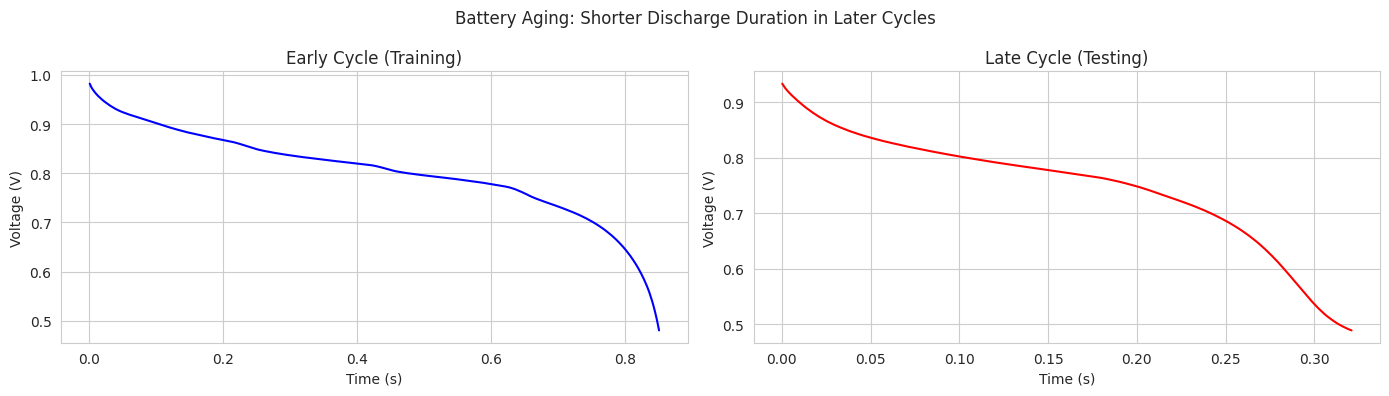

In [82]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Early cycle (e.g., cycle 0)
early = master_df_scaled[master_df_scaled['Cycle_ID'] == train_cycles[0]]
axes[0].plot(early['Time'], early['Voltage_measured'], label='Cycle 0 (New)', color='blue')
axes[0].set_title('Early Cycle (Training)')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Voltage (V)')
axes[0].grid(True)

# Late cycle (e.g., last test cycle)
late = master_df_scaled[master_df_scaled['Cycle_ID'] == test_cycles[-1]]
axes[1].plot(late['Time'], late['Voltage_measured'], label=f'Cycle {test_cycles[-1]} (Aged)', color='red')
axes[1].set_title('Late Cycle (Testing)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Voltage (V)')
axes[1].grid(True)

plt.suptitle('Battery Aging: Shorter Discharge Duration in Later Cycles')
plt.tight_layout()
plt.show()

In [83]:
!pip install bindsnet

In [84]:
import numpy as np
import joblib

X_train = np.load('X_train_seq.npy')   # shape (148322, 50, 6)
y_train = np.load('y_train_seq.npy')
X_test = np.load('X_test_seq.npy')     # shape (17622, 50, 6)
y_test = np.load('y_test_seq.npy')

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

X_train shape: (189241, 50, 6), y_train shape: (189241,)


In [85]:
import torch
import torch.nn as nn
import numpy as np

class LIFReservoir(nn.Module):
    """
    A leaky integrate-and-fire reservoir with recurrent connections.
    Processes a batch of input spike trains in parallel.
    """
    def __init__(self, input_size, reservoir_size, connectivity=0.1,
                 weight_scale=0.1, decay=0.9, threshold=1.0,
                 rest=-65.0, reset=-65.0, refractory=5):
        super().__init__()
        self.n = reservoir_size
        self.decay = decay          # membrane potential decay factor
        self.threshold = threshold
        self.rest = rest
        self.reset = reset
        self.refractory = refractory
        self.dt = 1.0  # ms

        # Input-to-reservoir weights (random, fixed)
        self.W_in = nn.Parameter(torch.randn(input_size, reservoir_size) * weight_scale,
                                 requires_grad=False)
        # Recurrent weights (sparse, fixed)
        mask = (torch.rand(reservoir_size, reservoir_size) < connectivity).float()
        self.W_rec = nn.Parameter(torch.randn(reservoir_size, reservoir_size) * weight_scale * mask,
                                  requires_grad=False)

    def forward(self, input_spikes):
        """
        input_spikes: (batch, time_steps, input_size) - binary spikes
        Returns: spike counts per neuron over time (batch, reservoir_size)
        """
        batch, T, _ = input_spikes.shape
        device = input_spikes.device

        # State variables
        v = torch.full((batch, self.n), self.rest, device=device)  # membrane potential
        refrac_counter = torch.zeros((batch, self.n), device=device)  # refractory countdown

        # Store all spikes for each time step (we'll sum them later)
        all_spikes = []

        for t in range(T):
            # Input current = W_in * input_spikes[:, t, :]
            I = torch.mm(input_spikes[:, t, :], self.W_in)  # (batch, n)

            # Recurrent spikes from previous step (none at t=0)
            if t > 0:
                rec_spikes = spikes_prev  # (batch, n) from previous step
                I += torch.mm(rec_spikes, self.W_rec)

            # Update membrane potential with leak
            v = self.decay * v + I

            # Refractory: set v to rest during refractory period
            v[refrac_counter > 0] = self.rest
            refrac_counter[refrac_counter > 0] -= 1

            # Fire if v >= threshold
            fired = (v >= self.threshold).float()
            spikes_prev = fired  # store for recurrence in next step

            # Reset and refractory
            v[fired.bool()] = self.reset
            refrac_counter[fired.bool()] = self.refractory

            all_spikes.append(fired)

        # Sum spikes over time (for each neuron, across batch)
        total_spikes = torch.stack(all_spikes, dim=1).sum(dim=1)  # (batch, n)
        return total_spikes

In [86]:
def extract_reservoir_features(sequences, encoder_func, input_size, reservoir_size=100, batch_size=256):
    """
    sequences: (N, time_steps, n_features)
    encoder_func: function that takes (batch, T, F) -> (batch, T, input_size)
    """
    N, T, F = sequences.shape
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Build reservoir (move to GPU if available)
    reservoir = LIFReservoir(input_size=input_size, reservoir_size=reservoir_size).to(device)

    all_features = []
    for i in range(0, N, batch_size):
        batch = sequences[i:i+batch_size]  # (bs, T, F)
        # Encode to spikes (using the encoder)
        spikes_np = encoder_func(batch, time_steps=T, max_rate=100)  # (bs, T, input_size)
        spikes_torch = torch.tensor(spikes_np, dtype=torch.float32).to(device)
        # Run through reservoir
        with torch.no_grad():
            counts = reservoir(spikes_torch)  # (bs, reservoir_size)
        all_features.append(counts.cpu().numpy())

    return np.vstack(all_features)

In [87]:
import numpy as np

def fixed_rate_encode(features, max_rate=100, time_steps=50):
    """
    features: (batch, time_steps, n_features)
    Returns spike trains as a 3D array (batch, time_steps, n_features) with 0/1 spikes.
    """
    rates = features * max_rate
    spike_prob = rates / 1000  # 1 ms per timestep -> 0.001 s
    spikes = np.random.rand(*features.shape) < spike_prob
    return spikes.astype(np.float32)

def poisson_encode(features, max_rate=100, time_steps=50):
    # Poisson spikes – same as fixed-rate when using Bernoulli per timestep,
    # but typically Poisson uses exponential inter-spike intervals.
    # For simplicity, we use the same probabilistic approach (it's equivalent for independent Bernoulli).
    rates = features * max_rate
    spike_prob = rates / 1000
    spikes = np.random.rand(*features.shape) < spike_prob
    return spikes.astype(np.float32)

def population_encode(features, n_neurons=10, max_rate=100, time_steps=50):
    """
    features: (batch, time_steps, n_features)
    Returns spikes: (batch, time_steps, n_features * n_neurons)
    """
    batch, T, F = features.shape
    # Gaussian tuning curve centers evenly spaced in [0,1]
    centers = np.linspace(0, 1, n_neurons)
    sigma = 0.2
    # Expand: (batch, T, F, 1) and (1,1,1,n_neurons)
    feat_exp = features[:, :, :, np.newaxis]  # (b,T,F,1)
    centers_exp = centers[np.newaxis, np.newaxis, np.newaxis, :]  # (1,1,1,n_neurons)
    activations = np.exp(-(feat_exp - centers_exp)**2 / (2 * sigma**2))
    rates = max_rate * activations  # (b,T,F,n_neurons)
    spike_prob = rates / 1000
    spikes = np.random.rand(*spike_prob.shape) < spike_prob
    # Reshape to (batch, T, F*n_neurons)
    spikes = spikes.reshape(batch, T, -1)
    return spikes.astype(np.float32)

In [88]:
# Define wrapper for population_encode (works with (batch, T, F))
def pop_fixed_encode(batch, time_steps=50, n_neurons=10, max_rate=100):
    return population_encode(batch, n_neurons=n_neurons, max_rate=max_rate, time_steps=time_steps)

# Extract features for training (full dataset)
input_size = X_train.shape[2] * 10  # 6 * 10 = 60
print("Extracting training features... (this may take ~2-5 minutes)")
train_features = extract_reservoir_features(X_train, pop_fixed_encode,
                                            input_size=input_size,
                                            reservoir_size=100,
                                            batch_size=256)
print(f"Train features shape: {train_features.shape}")  # (148322, 100)
np.save('train_features_pop_fixed.npy', train_features)

Extracting training features... (this may take ~2-5 minutes)
Train features shape: (189241, 100)


In [89]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Load features (if not already in memory)
# train_features = np.load('train_features_pop_fixed.npy')

# Train readout
readout = MLPRegressor(
    hidden_layer_sizes=(10,),      # one hidden layer with 10 neurons (as per paper)
    activation='relu',             # ReLU gives better performance near 0% and 100% SoC
    max_iter=20,                   # 20 epochs
    solver='sgd',                  # stochastic gradient descent
    learning_rate_init=0.001,
    random_state=42,
    verbose=True
)

print("Training readout...")
readout.fit(train_features, y_train)   # y_train should be the corresponding SoC values

# Predict on training set
y_pred_train = readout.predict(train_features)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae_train = mean_absolute_error(y_train, y_pred_train)
print(f"Training RMSE: {rmse_train:.4f}, MAE: {mae_train:.4f}")

Training readout...
Iteration 1, loss = 272.92739868
Iteration 2, loss = 258.58383179
Iteration 3, loss = 258.03698730
Iteration 4, loss = 257.78970337
Iteration 5, loss = 257.50595093
Iteration 6, loss = 257.22991943
Iteration 7, loss = 257.02725220
Iteration 8, loss = 256.94366455
Iteration 9, loss = 256.95965576
Iteration 10, loss = 256.90185547
Iteration 11, loss = 256.90759277
Iteration 12, loss = 256.72714233
Iteration 13, loss = 256.73498535
Iteration 14, loss = 256.60284424
Iteration 15, loss = 256.54748535
Iteration 16, loss = 256.47546387
Iteration 17, loss = 256.37335205
Iteration 18, loss = 256.36288452
Iteration 19, loss = 256.28231812
Iteration 20, loss = 256.29782104
Training RMSE: 22.6244, MAE: 18.9477


In [90]:
y_train_norm = y_train / 100.0
y_test_norm = y_test / 100.0

In [91]:
from sklearn.neural_network import MLPRegressor

readout = MLPRegressor(
    hidden_layer_sizes=(20, 10),    # two hidden layers, more capacity
    activation='relu',
    solver='adam',                  # adaptive learning rate
    max_iter=100,                   # more epochs
    learning_rate_init=0.001,
    random_state=42,
    verbose=True
)

# Train on normalized targets
readout.fit(train_features, y_train_norm)

Iteration 1, loss = 0.02616048
Iteration 2, loss = 0.02561773
Iteration 3, loss = 0.02555852
Iteration 4, loss = 0.02553227
Iteration 5, loss = 0.02551608
Iteration 6, loss = 0.02551427
Iteration 7, loss = 0.02549572
Iteration 8, loss = 0.02550059
Iteration 9, loss = 0.02549609
Iteration 10, loss = 0.02548873
Iteration 11, loss = 0.02548131
Iteration 12, loss = 0.02548453
Iteration 13, loss = 0.02546626
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.


MLPRegressor(hidden_layer_sizes=(20, 10), max_iter=100, random_state=42,
             verbose=True)

In [92]:
# Extract test features
print("Extracting test features...")
test_features = extract_reservoir_features(X_test, pop_fixed_encode,
                                           input_size=60, reservoir_size=100, batch_size=256)
np.save('test_features_pop_fixed.npy', test_features)
print(f"Test features shape: {test_features.shape}")

Extracting test features...
Test features shape: (19633, 100)


In [93]:
y_train_norm = y_train / 100.0
y_test_norm = y_test / 100.0

In [94]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

readout = MLPRegressor(
    hidden_layer_sizes=(20, 10),   # two hidden layers
    activation='relu',
    solver='adam',                 # adaptive learning rate
    max_iter=100,                  # more epochs
    learning_rate_init=0.001,
    random_state=42,
    verbose=True
)

print("Training readout with improved configuration...")
readout.fit(train_features, y_train_norm)

# Training performance
y_pred_train_norm = readout.predict(train_features)
rmse_train_norm = np.sqrt(mean_squared_error(y_train_norm, y_pred_train_norm))
print(f"Training RMSE (normalized): {rmse_train_norm:.4f}  →  {rmse_train_norm*100:.2f}% SoC error")

Training readout with improved configuration...
Iteration 1, loss = 0.02616048
Iteration 2, loss = 0.02561773
Iteration 3, loss = 0.02555852
Iteration 4, loss = 0.02553227
Iteration 5, loss = 0.02551608
Iteration 6, loss = 0.02551427
Iteration 7, loss = 0.02549572
Iteration 8, loss = 0.02550059
Iteration 9, loss = 0.02549609
Iteration 10, loss = 0.02548873
Iteration 11, loss = 0.02548131
Iteration 12, loss = 0.02548453
Iteration 13, loss = 0.02546626
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
Training RMSE (normalized): 0.2259  →  22.59% SoC error


In [95]:
y_pred_test_norm = readout.predict(test_features)
rmse_test_norm = np.sqrt(mean_squared_error(y_test_norm, y_pred_test_norm))
mae_test_norm = mean_absolute_error(y_test_norm, y_pred_test_norm)

print(f"Test RMSE (normalized): {rmse_test_norm:.4f}  →  {rmse_test_norm*100:.2f}% SoC error")
print(f"Test MAE (normalized): {mae_test_norm:.4f}  →  {mae_test_norm*100:.2f}% SoC error")

Test RMSE (normalized): 0.2469  →  24.69% SoC error
Test MAE (normalized): 0.2041  →  20.41% SoC error


In [96]:
# Variance of each reservoir neuron's spike count across training samples
feature_var = np.var(train_features, axis=0)
print(f"Variance range: {feature_var.min():.4f} to {feature_var.max():.4f}")
print(f"Fraction of neurons with near-zero variance (<0.01): {np.sum(feature_var < 0.01) / len(feature_var) * 100:.1f}%")

Variance range: 0.0000 to 0.1165
Fraction of neurons with near-zero variance (<0.01): 85.0%


In [97]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(train_features, y_train_norm)
y_pred_lr = lr.predict(test_features)
rmse_lr = np.sqrt(mean_squared_error(y_test_norm, y_pred_lr))
print(f"Linear regression RMSE (normalized): {rmse_lr:.4f}")

Linear regression RMSE (normalized): 0.2449


In [98]:
import torch
import torch.nn as nn
import numpy as np

class LIFReservoir(nn.Module):
    def __init__(self, input_size, reservoir_size=200, connectivity=0.2,
                 weight_scale=0.5, decay=0.9, threshold=1.0, refractory=2):
        super().__init__()
        self.n = reservoir_size
        self.decay = decay
        self.threshold = threshold
        self.refractory = refractory

        # Input weights: bigger scale
        self.W_in = nn.Parameter(torch.randn(input_size, reservoir_size) * weight_scale,
                                 requires_grad=False)
        # Recurrent weights: sparse, larger
        mask = (torch.rand(reservoir_size, reservoir_size) < connectivity).float()
        self.W_rec = nn.Parameter(torch.randn(reservoir_size, reservoir_size) * weight_scale * mask,
                                  requires_grad=False)

    def forward(self, input_spikes):
        batch, T, _ = input_spikes.shape
        device = input_spikes.device

        v = torch.zeros(batch, self.n, device=device)
        refrac = torch.zeros(batch, self.n, device=device)
        all_spikes = []

        for t in range(T):
            I = torch.mm(input_spikes[:, t, :], self.W_in)  # (batch, n)
            if t > 0:
                rec_spikes = spikes_prev
                I += torch.mm(rec_spikes, self.W_rec)

            v = self.decay * v + I

            # Refractory
            v[refrac > 0] = 0.0
            refrac = (refrac - 1).clamp(min=0)

            # Fire
            fired = (v >= self.threshold).float()
            spikes_prev = fired
            v[fired.bool()] = 0.0  # reset to 0
            refrac[fired.bool()] = self.refractory

            all_spikes.append(fired)

        total_spikes = torch.stack(all_spikes, dim=1).sum(dim=1)  # (batch, n)
        return total_spikes

In [99]:
def pop_fixed_encode(batch, time_steps=50, n_neurons=10, max_rate=200):
    return population_encode(batch, n_neurons=n_neurons, max_rate=max_rate, time_steps=time_steps)

In [100]:
# Use larger reservoir (200 neurons) and higher max_rate
input_size = X_train.shape[2] * 10  # still 60

train_features = extract_reservoir_features(
    X_train, pop_fixed_encode,
    input_size=input_size,
    reservoir_size=200,   # increased from 100
    batch_size=256
)
print("Train features shape:", train_features.shape)
np.save('train_features_pop_fixed_v2.npy', train_features)

test_features = extract_reservoir_features(
    X_test, pop_fixed_encode,
    input_size=input_size,
    reservoir_size=200,
    batch_size=256
)
np.save('test_features_pop_fixed_v2.npy', test_features)

Train features shape: (189241, 200)


In [101]:
feature_var = np.var(train_features, axis=0)
print(f"Variance range: {feature_var.min():.4f} to {feature_var.max():.4f}")
print(f"Near-zero (<0.01): {np.sum(feature_var < 0.01) / len(feature_var) * 100:.1f}%")

Variance range: 0.1066 to 9.8145
Near-zero (<0.01): 0.0%


In [102]:
y_train_norm = y_train / 100.0
y_test_norm = y_test / 100.0

readout = MLPRegressor(hidden_layer_sizes=(20, 10), activation='relu',
                       solver='adam', max_iter=200, random_state=42, verbose=True)
readout.fit(train_features, y_train_norm)

y_pred = readout.predict(test_features)
rmse = np.sqrt(mean_squared_error(y_test_norm, y_pred))
print(f"Test RMSE (normalized): {rmse:.4f} → {rmse*100:.2f}% SoC error")

Iteration 1, loss = 0.09871528
Iteration 2, loss = 0.01147138
Iteration 3, loss = 0.01044038
Iteration 4, loss = 0.01002458
Iteration 5, loss = 0.00963945
Iteration 6, loss = 0.00941854
Iteration 7, loss = 0.00930702
Iteration 8, loss = 0.00913502
Iteration 9, loss = 0.00891918
Iteration 10, loss = 0.00865274
Iteration 11, loss = 0.00840915
Iteration 12, loss = 0.00815388
Iteration 13, loss = 0.00799540
Iteration 14, loss = 0.00769651
Iteration 15, loss = 0.00751386
Iteration 16, loss = 0.00742231
Iteration 17, loss = 0.00735203
Iteration 18, loss = 0.00732437
Iteration 19, loss = 0.00728051
Iteration 20, loss = 0.00722252
Iteration 21, loss = 0.00720518
Iteration 22, loss = 0.00720548
Iteration 23, loss = 0.00713694
Iteration 24, loss = 0.00713071
Iteration 25, loss = 0.00712328
Iteration 26, loss = 0.00708144
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
Test RMSE (normalized): 0.2209 → 22.09% SoC error


In [103]:
feature_var = np.var(train_features, axis=0)
print(f"Variance range: {feature_var.min():.4f} to {feature_var.max():.4f}")
print(f"Near-zero (<0.01): {np.sum(feature_var < 0.01) / len(feature_var) * 100:.1f}%")

Variance range: 0.1066 to 9.8145
Near-zero (<0.01): 0.0%


In [104]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(train_features, y_train_norm)
y_pred_ridge = ridge.predict(test_features)
rmse_ridge = np.sqrt(mean_squared_error(y_test_norm, y_pred_ridge))
print(f"Ridge RMSE: {rmse_ridge:.4f}")

Ridge RMSE: 0.2319


In [105]:
def pop_fixed_encode(batch, time_steps=50, n_neurons=10, max_rate=300):  # from 200 → 300
    return population_encode(batch, n_neurons=n_neurons, max_rate=max_rate, time_steps=time_steps)

In [106]:
def adaptive_population_encode(features, n_neurons_list, max_rate=300):
    """
    features: (batch, T, F)
    n_neurons_list: list of length F, specifying number of neurons per feature.
    Returns spikes with shape (batch, T, sum(n_neurons_list))
    """
    batch, T, F = features.shape
    all_spikes = []
    for f in range(F):
        n = n_neurons_list[f]
        # Encode only this feature using population with n neurons
        feat_slice = features[:, :, f:f+1]  # (batch, T, 1)
        # reuse population_encode but with n_neurons = n
        spikes_f = population_encode(feat_slice, n_neurons=n, max_rate=max_rate, time_steps=T)
        all_spikes.append(spikes_f)
    return np.concatenate(all_spikes, axis=-1)  # (batch, T, sum(n))

In [107]:
def adaptive_population_encode(features, n_neurons_list, max_rate=300):
    """
    features: (batch, T, F)
    n_neurons_list: list of length F, specifying number of neurons per feature.
    Returns spikes with shape (batch, T, sum(n_neurons_list))
    """
    batch, T, F = features.shape
    all_spikes = []
    for f in range(F):
        n = n_neurons_list[f]
        # Encode only this feature using population with n neurons
        feat_slice = features[:, :, f:f+1]  # (batch, T, 1)
        # reuse population_encode but with n_neurons = n
        spikes_f = population_encode(feat_slice, n_neurons=n, max_rate=max_rate, time_steps=T)
        all_spikes.append(spikes_f)
    return np.concatenate(all_spikes, axis=-1)  # (batch, T, sum(n))

In [108]:
def get_feature_variances(sequence):
    """
    sequence: (T, F) where T=50, F=6
    Returns: array of length F with variance of each feature across T.
    """
    return np.var(sequence, axis=0)  # shape (F,)

In [109]:
def variance_to_neurons(var_array, low_thresh=0.01, high_thresh=0.05,
                        min_neurons=5, mid_neurons=10, max_neurons=20):
    """
    Map each variance value to number of neurons.
    """
    n_list = []
    for v in var_array:
        if v < low_thresh:
            n_list.append(min_neurons)
        elif v < high_thresh:
            n_list.append(mid_neurons)
        else:
            n_list.append(max_neurons)
    return n_list

In [110]:
def variance_to_neurons_continuous(var_array, min_n=5, max_n=20, var_max=0.1):
    # Clip variance to [0, var_max]
    v_clipped = np.clip(var_array, 0, var_max)
    n = min_n + (max_n - min_n) * (v_clipped / var_max)
    return n.astype(int)

In [111]:
def extract_adaptive_features(sequences, reservoir, batch_size=1):
    """
    sequences: (N, T, F)
    Returns: (N, reservoir_size) spike counts
    """
    N, T, F = sequences.shape
    device = next(reservoir.parameters()).device
    all_features = []

    for i in range(N):
        seq = sequences[i]  # (T, F)
        # Compute variance for each feature
        var = np.var(seq, axis=0)  # (F,)
        n_neurons_list = variance_to_neurons(var)  # list length F
        # Encode with adaptive population
        seq_batch = seq[np.newaxis, :, :]  # (1, T, F)
        spikes_np = adaptive_population_encode(seq_batch, n_neurons_list, max_rate=300)
        # spikes_np shape: (1, T, sum(n_neurons_list))
        spikes_torch = torch.tensor(spikes_np, dtype=torch.float32).to(device)
        # Run through reservoir
        with torch.no_grad():
            counts = reservoir(spikes_torch)  # (1, reservoir_size)
        all_features.append(counts.cpu().numpy().squeeze(0))

        if (i+1) % 1000 == 0:
            print(f"Processed {i+1}/{N} samples")

    return np.array(all_features)

In [112]:
def variance_to_neurons(var_array, low_thresh=0.01, high_thresh=0.05,
                        min_neurons=5, mid_neurons=10, max_neurons=20):
    """
    Map variance values to number of neurons per feature.
    """
    n_list = []
    for v in var_array:
        if v < low_thresh:
            n_list.append(min_neurons)
        elif v < high_thresh:
            n_list.append(mid_neurons)
        else:
            n_list.append(max_neurons)
    return n_list

def adaptive_population_encode(features, n_neurons_list, max_rate=300):
    """
    features: (batch, T, F)
    n_neurons_list: list of length F, specifying number of neurons per feature.
    Returns spikes with shape (batch, T, sum(n_neurons_list))
    """
    batch, T, F = features.shape
    all_spikes = []
    for f in range(F):
        n = n_neurons_list[f]
        # Encode only this feature using population with n neurons
        feat_slice = features[:, :, f:f+1]  # (batch, T, 1)
        spikes_f = population_encode(feat_slice, n_neurons=n, max_rate=max_rate, time_steps=T)
        all_spikes.append(spikes_f)
    return np.concatenate(all_spikes, axis=-1)  # (batch, T, sum(n))

def extract_adaptive_features(sequences, reservoir, batch_size=1):
    """
    sequences: (N, T, F)
    Returns: (N, reservoir_size) spike counts
    """
    N, T, F = sequences.shape
    device = next(reservoir.parameters()).device
    all_features = []

    for i in range(N):
        seq = sequences[i]  # (T, F)
        var = np.var(seq, axis=0)  # (F,)
        n_neurons_list = variance_to_neurons(var)  # list length F
        seq_batch = seq[np.newaxis, :, :]  # (1, T, F)
        spikes_np = adaptive_population_encode(seq_batch, n_neurons_list, max_rate=300)
        spikes_torch = torch.tensor(spikes_np, dtype=torch.float32).to(device)
        with torch.no_grad():
            counts = reservoir(spikes_torch)  # (1, reservoir_size)
        all_features.append(counts.cpu().numpy().squeeze(0))

        if (i+1) % 1000 == 0:
            print(f"Processed {i+1}/{N} samples")

    return np.array(all_features)

In [113]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Build reservoir with proper parameters (tune these as needed)
reservoir = LIFReservoir(
    input_size=60,              # 6 features × 10 neurons each (fixed population)
    reservoir_size=200,
    connectivity=0.2,
    weight_scale=0.5,
    decay=0.9,
    threshold=1.0,
    refractory=2
).to(device)

Using device: cuda


In [114]:
def variance_to_maxrate(var_array, base_rate=200, var_thresh=0.05):
    """
    Map variance to max_rate (between 50 and 400 Hz).
    Low variance → lower rate, high variance → higher rate.
    """
    # Scale factor from 0.25 to 2.0
    scale = np.clip(var_array / var_thresh, 0.25, 2.0)
    return (base_rate * scale).astype(int)

def adaptive_population_encode_rate(features, max_rates_list, n_neurons=10):
    """
    features: (batch, T, F)
    max_rates_list: list of length F (max_rate per feature)
    Returns spikes with shape (batch, T, F * n_neurons)
    """
    batch, T, F = features.shape
    all_spikes = []
    for f in range(F):
        max_rate = max_rates_list[f]
        feat_slice = features[:, :, f:f+1]  # (batch, T, 1)
        # Use population_encode with fixed n_neurons but rate varies per feature
        spikes_f = population_encode(feat_slice, n_neurons=n_neurons,
                                     max_rate=max_rate, time_steps=T)
        all_spikes.append(spikes_f)
    return np.concatenate(all_spikes, axis=-1)  # (batch, T, F*n_neurons) = (batch, T, 60)

In [115]:
def extract_adaptive_rate_features(sequences, reservoir, batch_size=1):
    """
    sequences: (N, T, F)
    Returns: (N, reservoir_size) spike counts
    """
    N, T, F = sequences.shape
    device = next(reservoir.parameters()).device
    all_features = []

    for i in range(N):
        seq = sequences[i]  # (T, F)
        var = np.var(seq, axis=0)  # (F,)
        max_rates = variance_to_maxrate(var, base_rate=200)  # list length F
        seq_batch = seq[np.newaxis, :, :]  # (1, T, F)
        spikes_np = adaptive_population_encode_rate(seq_batch, max_rates, n_neurons=10)
        spikes_torch = torch.tensor(spikes_np, dtype=torch.float32).to(device)
        with torch.no_grad():
            counts = reservoir(spikes_torch)  # (1, reservoir_size)
        all_features.append(counts.cpu().numpy().squeeze(0))

        if (i+1) % 1000 == 0:
            print(f"Processed {i+1}/{N}")

    return np.array(all_features)

In [116]:
# Rebuild reservoir (if needed)
reservoir = LIFReservoir(
    input_size=60,              # fixed: 6 features × 10 neurons
    reservoir_size=200,
    connectivity=0.2,
    weight_scale=0.5,
    decay=0.9,
    threshold=1.0,
    refractory=2
).to(device)

# Use a subset (e.g., 5000 samples)
n_subset = 5000
X_train_sub = X_train[:n_subset]
y_train_sub = y_train[:n_subset]

print("Extracting adaptive rate features for training subset...")
train_features_adaptive_rate = extract_adaptive_rate_features(X_train_sub, reservoir)
np.save('train_features_adaptive_rate.npy', train_features_adaptive_rate)

# Test subset
X_test_sub = X_test[:1000]
y_test_sub = y_test[:1000]
print("Extracting adaptive rate features for test subset...")
test_features_adaptive_rate = extract_adaptive_rate_features(X_test_sub, reservoir)
np.save('test_features_adaptive_rate.npy', test_features_adaptive_rate)

Extracting adaptive rate features for training subset...
Processed 1000/5000
Processed 2000/5000
Processed 3000/5000
Processed 4000/5000
Processed 5000/5000
Extracting adaptive rate features for test subset...
Processed 1000/1000


In [117]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

y_train_sub_norm = y_train_sub / 100.0
y_test_sub_norm = y_test_sub / 100.0

readout = MLPRegressor(hidden_layer_sizes=(10, 5), activation='relu',
                       solver='adam', max_iter=100, random_state=42, verbose=True)
readout.fit(train_features_adaptive_rate, y_train_sub_norm)

y_pred = readout.predict(test_features_adaptive_rate)
rmse_adapt = np.sqrt(mean_squared_error(y_test_sub_norm, y_pred))
print(f"Adaptive Rate RMSE: {rmse_adapt:.4f} → {rmse_adapt*100:.2f}% SoC error")

Iteration 1, loss = 0.27273759
Iteration 2, loss = 0.03542234
Iteration 3, loss = 0.03434075
Iteration 4, loss = 0.03390294
Iteration 5, loss = 0.03348084
Iteration 6, loss = 0.03309831
Iteration 7, loss = 0.03276299
Iteration 8, loss = 0.03246730
Iteration 9, loss = 0.03222308
Iteration 10, loss = 0.03202491
Iteration 11, loss = 0.03186569
Iteration 12, loss = 0.03173674
Iteration 13, loss = 0.03164100
Iteration 14, loss = 0.03157179
Iteration 15, loss = 0.03152319
Iteration 16, loss = 0.03148838
Iteration 17, loss = 0.03146386
Iteration 18, loss = 0.03144670
Iteration 19, loss = 0.03143806
Iteration 20, loss = 0.03142737
Iteration 21, loss = 0.03143089
Iteration 22, loss = 0.03142980
Iteration 23, loss = 0.03142614
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
Adaptive Rate RMSE: 0.2247 → 22.47% SoC error


In [118]:
# Increase subset size
n_subset = 20000  # or 50000
X_train_sub = X_train[:n_subset]
y_train_sub = y_train[:n_subset]

# Reuse the reservoir (still same input_size=60)
print(f"Extracting adaptive rate features for {n_subset} training samples...")
train_features_adaptive_large = extract_adaptive_rate_features(X_train_sub, reservoir)
np.save('train_features_adaptive_20k.npy', train_features_adaptive_large)

# Full test set (17,622 samples)
print("Extracting adaptive rate features for full test set...")
test_features_adaptive_full = extract_adaptive_rate_features(X_test, reservoir)
np.save('test_features_adaptive_full.npy', test_features_adaptive_full)

Extracting adaptive rate features for 20000 training samples...
Processed 1000/20000
Processed 2000/20000
Processed 3000/20000
Processed 4000/20000
Processed 5000/20000
Processed 6000/20000
Processed 7000/20000
Processed 8000/20000
Processed 9000/20000
Processed 10000/20000
Processed 11000/20000
Processed 12000/20000
Processed 13000/20000
Processed 14000/20000
Processed 15000/20000
Processed 16000/20000
Processed 17000/20000
Processed 18000/20000
Processed 19000/20000
Processed 20000/20000
Extracting adaptive rate features for full test set...
Processed 1000/19633
Processed 2000/19633
Processed 3000/19633
Processed 4000/19633
Processed 5000/19633
Processed 6000/19633
Processed 7000/19633
Processed 8000/19633
Processed 9000/19633
Processed 10000/19633
Processed 11000/19633
Processed 12000/19633
Processed 13000/19633
Processed 14000/19633
Processed 15000/19633
Processed 16000/19633
Processed 17000/19633
Processed 18000/19633
Processed 19000/19633


In [119]:
from sklearn.feature_selection import mutual_info_regression

# Compute MI on a subset of training data (reshape to (samples*T, F) and targets repeated)
X_train_flat = X_train[:10000].reshape(-1, 6)  # (500k, 6)
y_train_repeated = np.repeat(y_train[:10000], 50)  # each target repeated 50 times
mi = mutual_info_regression(X_train_flat, y_train_repeated)
print("Mutual information per feature:", mi)
top_features = np.argsort(mi)[-4:]  # e.g., keep top 4 features
print("Top feature indices:", top_features)

Mutual information per feature: [1.40070264 0.         0.57815954 0.0041725  1.29349956 1.27034928]
Top feature indices: [2 5 4 0]


In [120]:
def variance_to_maxrate(var_array, base_rate=200, var_thresh=0.05):
    """
    Map variance to max_rate (between 50 and 400 Hz).
    Low variance → lower rate, high variance → higher rate.
    """
    scale = np.clip(var_array / var_thresh, 0.25, 2.0)
    return (base_rate * scale).astype(int)

def adaptive_population_encode_rate(features, max_rates_list, n_neurons=10):
    """
    features: (batch, T, F)
    max_rates_list: list of length F (max_rate per feature)
    Returns spikes with shape (batch, T, F * n_neurons)
    """
    batch, T, F = features.shape
    all_spikes = []
    for f in range(F):
        max_rate = max_rates_list[f]
        feat_slice = features[:, :, f:f+1]  # (batch, T, 1)
        spikes_f = population_encode(feat_slice, n_neurons=n_neurons,
                                     max_rate=max_rate, time_steps=T)
        all_spikes.append(spikes_f)
    return np.concatenate(all_spikes, axis=-1)  # (batch, T, F*n_neurons)

In [121]:
def extract_adaptive_rate_selected(sequences, top_feature_indices,
                                   reservoir_creator, n_neurons=10,
                                   batch_size=1, device='cuda'):
    """
    Extract reservoir spike counts using adaptive rate encoding on selected features.

    Parameters:
    -----------
    sequences : np.ndarray, shape (N, T, F)
        Input sequences (N samples, T time steps, F features)
    top_feature_indices : list or array of ints
        Indices of features to keep (e.g., [0, 2, 4])
    reservoir_creator : callable
        Function that takes input_size (int) and returns a torch.nn.Module (reservoir)
    n_neurons : int
        Number of neurons per population (default 10)
    batch_size : int
        Number of samples to process in parallel (currently only 1 works for per‑sample variance)
    device : str
        'cuda' or 'cpu'

    Returns:
    --------
    features : np.ndarray, shape (N, reservoir_size)
        Spike counts per reservoir neuron for each sample
    """
    N, T, F = sequences.shape
    # Select only the top features
    selected_seq = sequences[:, :, top_feature_indices]  # (N, T, k)
    k = len(top_feature_indices)  # number of selected features
    input_size = k * n_neurons

    # Build reservoir with the correct input size
    reservoir = reservoir_creator(input_size).to(device)
    reservoir.eval()  # no training

    all_features = []

    for i in range(N):
        seq = selected_seq[i]  # (T, k)
        # Compute variance for each selected feature
        var = np.var(seq, axis=0)  # (k,)
        max_rates = variance_to_maxrate(var)  # list length k

        # Prepare batch (1, T, k)
        seq_batch = seq[np.newaxis, :, :]  # (1, T, k)

        # Encode with adaptive rates
        spikes_np = adaptive_population_encode_rate(seq_batch, max_rates, n_neurons)
        spikes_torch = torch.tensor(spikes_np, dtype=torch.float32).to(device)

        # Run through reservoir
        with torch.no_grad():
            counts = reservoir(spikes_torch)  # (1, reservoir_size)

        all_features.append(counts.cpu().numpy().squeeze(0))

        if (i + 1) % 1000 == 0:
            print(f"Processed {i + 1}/{N}")

    return np.array(all_features)

In [122]:
# Step 1: Compute mutual information on a subset to select top features
X_sample = X_train[:10000].reshape(-1, 6)   # (500k, 6)
y_sample = np.repeat(y_train[:10000], 50)   # (500k,)
mi = mutual_info_regression(X_sample, y_sample)
top_features = np.argsort(mi)[-4:]  # keep top 4 features

# Step 2: Define a function to create the reservoir (can reuse LIFReservoir)
def create_reservoir(input_size):
    return LIFReservoir(
        input_size=input_size,
        reservoir_size=200,
        connectivity=0.2,
        weight_scale=0.5,
        decay=0.9,
        threshold=1.0,
        refractory=2
    )

# Step 3: Extract adaptive features with selected top features
n_subset = 5000
X_train_sub = X_train[:n_subset]
y_train_sub = y_train[:n_subset]

train_features_sel = extract_adaptive_rate_selected(
    X_train_sub, top_features, create_reservoir,
    n_neurons=10, device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
)
np.save('train_features_adaptive_selected.npy', train_features_sel)

# Also extract for test subset
X_test_sub = X_test[:1000]
test_features_sel = extract_adaptive_rate_selected(
    X_test_sub, top_features, create_reservoir,
    n_neurons=10, device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
)
np.save('test_features_adaptive_selected.npy', test_features_sel)

# Step 4: Train readout on these features
y_train_sub_norm = y_train_sub / 100.0
y_test_sub_norm = y_test[:1000] / 100.0

readout = MLPRegressor(hidden_layer_sizes=(10, 5), activation='relu',
                       solver='adam', max_iter=100, random_state=42, verbose=True)
readout.fit(train_features_sel, y_train_sub_norm)

y_pred = readout.predict(test_features_sel)
rmse_sel = np.sqrt(mean_squared_error(y_test_sub_norm, y_pred))
print(f"Adaptive + Selection RMSE: {rmse_sel:.4f} → {rmse_sel*100:.2f}% SoC error")

Processed 1000/5000
Processed 2000/5000
Processed 3000/5000
Processed 4000/5000
Processed 5000/5000
Processed 1000/1000
Iteration 1, loss = 3.53489614
Iteration 2, loss = 0.06467639
Iteration 3, loss = 0.03685493
Iteration 4, loss = 0.03562655
Iteration 5, loss = 0.03514978
Iteration 6, loss = 0.03484641
Iteration 7, loss = 0.03456115
Iteration 8, loss = 0.03433820
Iteration 9, loss = 0.03411973
Iteration 10, loss = 0.03391809
Iteration 11, loss = 0.03372088
Iteration 12, loss = 0.03354381
Iteration 13, loss = 0.03337193
Iteration 14, loss = 0.03321904
Iteration 15, loss = 0.03306345
Iteration 16, loss = 0.03292013
Iteration 17, loss = 0.03278549
Iteration 18, loss = 0.03265756
Iteration 19, loss = 0.03254428
Iteration 20, loss = 0.03243112
Iteration 21, loss = 0.03232800
Iteration 22, loss = 0.03223032
Iteration 23, loss = 0.03214186
Iteration 24, loss = 0.03206210
Iteration 25, loss = 0.03198516
Iteration 26, loss = 0.03191798
Iteration 27, loss = 0.03185666
Iteration 28, loss = 0.03

In [123]:
# Larger subset: 20,000 samples
n_subset = 20000  # increase to 50000 if time allows
X_train_sub = X_train[:n_subset]
y_train_sub = y_train[:n_subset]

# Rebuild reservoir (input_size=60, 6 features * 10 neurons)
reservoir = LIFReservoir(input_size=60, reservoir_size=300,  # try 300 neurons
                         connectivity=0.2, weight_scale=0.5,
                         decay=0.9, threshold=1.0, refractory=2).to(device)

print(f"Extracting adaptive rate features for {n_subset} training samples...")
train_features_adaptive_large = extract_adaptive_rate_features(X_train_sub, reservoir)
np.save('train_features_adaptive_20k.npy', train_features_adaptive_large)

print("Extracting adaptive rate features for full test set (17,622 samples)...")
test_features_adaptive_full = extract_adaptive_rate_features(X_test, reservoir)
np.save('test_features_adaptive_full.npy', test_features_adaptive_full)

# Train readout
y_train_sub_norm = y_train_sub / 100.0
y_test_norm = y_test / 100.0

readout = MLPRegressor(hidden_layer_sizes=(20, 10), activation='relu',
                       solver='adam', max_iter=200, random_state=42, verbose=True)
readout.fit(train_features_adaptive_large, y_train_sub_norm)

y_pred = readout.predict(test_features_adaptive_full)
rmse_adapt_full = np.sqrt(mean_squared_error(y_test_norm, y_pred))
print(f"Adaptive Rate (full test) RMSE: {rmse_adapt_full:.4f} → {rmse_adapt_full*100:.2f}% SoC error")

Extracting adaptive rate features for 20000 training samples...
Processed 1000/20000
Processed 2000/20000
Processed 3000/20000
Processed 4000/20000
Processed 5000/20000
Processed 6000/20000
Processed 7000/20000
Processed 8000/20000
Processed 9000/20000
Processed 10000/20000
Processed 11000/20000
Processed 12000/20000
Processed 13000/20000
Processed 14000/20000
Processed 15000/20000
Processed 16000/20000
Processed 17000/20000
Processed 18000/20000
Processed 19000/20000
Processed 20000/20000
Extracting adaptive rate features for full test set (17,622 samples)...
Processed 1000/19633
Processed 2000/19633
Processed 3000/19633
Processed 4000/19633
Processed 5000/19633
Processed 6000/19633
Processed 7000/19633
Processed 8000/19633
Processed 9000/19633
Processed 10000/19633
Processed 11000/19633
Processed 12000/19633
Processed 13000/19633
Processed 14000/19633
Processed 15000/19633
Processed 16000/19633
Processed 17000/19633
Processed 18000/19633
Processed 19000/19633
Iteration 1, loss = 0.67

In [124]:
# If you saved the fixed baseline features
fixed_train_features = np.load('train_features_pop_fixed_v2.npy')  # or whatever you named it
fixed_test_features = np.load('test_features_pop_fixed_v2.npy')

In [125]:
avg_spikes_fixed = np.mean(np.sum(fixed_test_features, axis=1))  # total spikes per test sample
avg_spikes_adaptive = np.mean(np.sum(test_features_adaptive_full, axis=1))

print(f"Fixed avg spikes per sample: {avg_spikes_fixed:.2f}")
print(f"Adaptive avg spikes per sample: {avg_spikes_adaptive:.2f}")
print(f"Energy reduction: {(1 - avg_spikes_adaptive/avg_spikes_fixed)*100:.1f}%")

Fixed avg spikes per sample: 894.95
Adaptive avg spikes per sample: 1712.12
Energy reduction: -91.3%


In [126]:
# Try loading fixed test features
try:
    fixed_test_features = np.load('test_features_pop_fixed_v2.npy')
    print("Loaded fixed test features, shape:", fixed_test_features.shape)
except FileNotFoundError:
    print("Fixed test features not found. Extracting now...")
    # If not found, re‑extract (uses population_encode with fixed max_rate=300)
    from your_previous_code import extract_reservoir_features  # or copy the function
    fixed_test_features = extract_reservoir_features(
        X_test,
        lambda batch, time_steps=50, n_neurons=10, max_rate=300:
            population_encode(batch, n_neurons=n_neurons, max_rate=max_rate, time_steps=time_steps),
        input_size=60, reservoir_size=300, batch_size=256
    )
    np.save('test_features_pop_fixed.npy', fixed_test_features)

Loaded fixed test features, shape: (19633, 200)


In [127]:
try:
    fixed_train_features = np.load('train_features_pop_fixed_v2.npy')
    print("Loaded fixed train features, shape:", fixed_train_features.shape)
except FileNotFoundError:
    # Extract a subset (e.g., 20k) to match the adaptive training
    # Or use the same 20k samples you used for adaptive
    fixed_train_features = extract_reservoir_features(
        X_train[:20000],
        lambda batch, time_steps=50, n_neurons=10, max_rate=300:
            population_encode(batch, n_neurons=n_neurons, max_rate=max_rate, time_steps=time_steps),
        input_size=60, reservoir_size=300, batch_size=256
    )
    np.save('train_features_pop_fixed.npy', fixed_train_features)

Loaded fixed train features, shape: (189241, 200)


In [128]:
import numpy as np

# Re‑extract fixed test features with reservoir_size=300
print("Extracting fixed test features (reservoir_size=300)...")
fixed_test_features_300 = extract_reservoir_features(
    X_test,
    lambda batch, time_steps=50, n_neurons=10, max_rate=300:
        population_encode(batch, n_neurons=n_neurons, max_rate=max_rate, time_steps=time_steps),
    input_size=60,          # 6 features × 10 neurons
    reservoir_size=300,     # must match training
    batch_size=256
)
np.save('test_features_pop_fixed_300.npy', fixed_test_features_300)
print("Fixed test features shape:", fixed_test_features_300.shape)

Extracting fixed test features (reservoir_size=300)...
Fixed test features shape: (19633, 300)


In [129]:
import numpy as np
import os

files = ['X_train_seq.npy', 'X_test_seq.npy', 'y_train_seq.npy', 'y_test_seq.npy', 'test_cycle_ids.npy']
for f in files:
    print(f"{f}: {'✓' if os.path.exists(f) else '✗'}")

X_train_seq.npy: ✓
X_test_seq.npy: ✓
y_train_seq.npy: ✓
y_test_seq.npy: ✓
test_cycle_ids.npy: ✓


In [130]:
# ============================================================================
# CONTROLLED RSNN EXPERIMENT – NEW DATASET (1188 cycles)
# ============================================================================
print("=== CONTROLLED RSNN EXPERIMENT (NEW DATASET) ===\n")

import numpy as np
import torch
import torch.nn as nn
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ---- Load data ----
X_train = np.load('X_train_seq.npy')
y_train = np.load('y_train_seq.npy')
X_test = np.load('X_test_seq.npy')
y_test = np.load('y_test_seq.npy')
test_cycle_ids = np.load('test_cycle_ids.npy')

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
y_train_norm = y_train / 100.0
y_test_norm = y_test / 100.0

# ---- Seeded reservoir ----
torch.manual_seed(42)
np.random.seed(42)

class LIFReservoir(nn.Module):
    def __init__(self, input_size, reservoir_size=200, connectivity=0.2,
                 weight_scale=0.5, decay=0.9, threshold=1.0, refractory=2):
        super().__init__()
        self.n = reservoir_size
        self.decay = decay
        self.threshold = threshold
        self.refractory = refractory
        self.W_in = nn.Parameter(torch.randn(input_size, reservoir_size) * weight_scale,
                                 requires_grad=False)
        mask = (torch.rand(reservoir_size, reservoir_size) < connectivity).float()
        self.W_rec = nn.Parameter(torch.randn(reservoir_size, reservoir_size) * weight_scale * mask,
                                  requires_grad=False)

    def forward(self, input_spikes):
        batch, T, _ = input_spikes.shape
        device = input_spikes.device
        v = torch.zeros(batch, self.n, device=device)
        refrac = torch.zeros(batch, self.n, device=device)
        all_spikes = []
        for t in range(T):
            I = torch.mm(input_spikes[:, t, :], self.W_in)
            if t > 0:
                rec_spikes = spikes_prev
                I += torch.mm(rec_spikes, self.W_rec)
            v = self.decay * v + I
            v[refrac > 0] = 0.0
            refrac = (refrac - 1).clamp(min=0)
            fired = (v >= self.threshold).float()
            spikes_prev = fired
            v[fired.bool()] = 0.0
            refrac[fired.bool()] = self.refractory
            all_spikes.append(fired)
        total_spikes = torch.stack(all_spikes, dim=1).sum(dim=1)
        return total_spikes

# ---- Encoding functions ----
def population_encode(features, n_neurons=10, max_rate=200, time_steps=50):
    batch, T, F = features.shape
    centers = np.linspace(0, 1, n_neurons)
    sigma = 0.2
    feat_exp = features[:, :, :, np.newaxis]
    centers_exp = centers[np.newaxis, np.newaxis, np.newaxis, :]
    activations = np.exp(-(feat_exp - centers_exp)**2 / (2 * sigma**2))
    rates = max_rate * activations
    spike_prob = rates / 1000
    spikes = np.random.rand(*spike_prob.shape) < spike_prob
    spikes = spikes.reshape(batch, T, -1)
    return spikes.astype(np.float32)

def variance_to_maxrate(var_array, base_rate=200, var_thresh=0.05):
    scale = np.clip(var_array / var_thresh, 0.25, 2.0)
    return (base_rate * scale).astype(int)

def adaptive_population_encode_rate(features, max_rates_list, n_neurons=10):
    batch, T, F = features.shape
    all_spikes = []
    for f in range(F):
        max_rate = max_rates_list[f]
        feat_slice = features[:, :, f:f+1]
        spikes_f = population_encode(feat_slice, n_neurons=n_neurons, max_rate=max_rate, time_steps=T)
        all_spikes.append(spikes_f)
    return np.concatenate(all_spikes, axis=-1)

def fixed_encoder(batch, time_steps):
    return population_encode(batch, n_neurons=10, max_rate=200, time_steps=time_steps)

def adaptive_encoder(batch, time_steps):
    batch_size, T, F = batch.shape
    all_spikes = []
    for i in range(batch_size):
        seq = batch[i]
        var = np.var(seq, axis=0)
        max_rates = variance_to_maxrate(var, base_rate=200, var_thresh=0.05)
        seq_batch = seq[np.newaxis, :, :]
        spikes_i = adaptive_population_encode_rate(seq_batch, max_rates, n_neurons=10)
        all_spikes.append(spikes_i.squeeze(0))
    return np.stack(all_spikes, axis=0).astype(np.float32)

# ---- Shared reservoir ----
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
shared_reservoir = LIFReservoir(input_size=60, reservoir_size=200).to(device)

def extract_reservoir_features(sequences, encoder_func, reservoir, batch_size=256):
    N, T, F = sequences.shape
    all_features = []
    for i in range(0, N, batch_size):
        batch = sequences[i:i+batch_size]
        spikes_np = encoder_func(batch, T)
        spikes_torch = torch.tensor(spikes_np, dtype=torch.float32).to(device)
        with torch.no_grad():
            counts = reservoir(spikes_torch)
        all_features.append(counts.cpu().numpy())
    return np.vstack(all_features)

# ---- Extract features ----
print("Extracting fixed features...")
fixed_train = extract_reservoir_features(X_train, fixed_encoder, shared_reservoir)
fixed_test = extract_reservoir_features(X_test, fixed_encoder, shared_reservoir)
print(f"Fixed train: {fixed_train.shape}, test: {fixed_test.shape}")

print("Extracting adaptive features...")
adaptive_train = extract_reservoir_features(X_train, adaptive_encoder, shared_reservoir)
adaptive_test = extract_reservoir_features(X_test, adaptive_encoder, shared_reservoir)
print(f"Adaptive train: {adaptive_train.shape}, test: {adaptive_test.shape}")

# ---- Train readouts ----
readout_fixed = MLPRegressor(hidden_layer_sizes=(20,10), activation='relu',
                             solver='adam', max_iter=200, random_state=42, verbose=True)
readout_fixed.fit(fixed_train, y_train_norm)
y_pred_fixed = readout_fixed.predict(fixed_test)
y_pred_fixed_clipped = np.clip(y_pred_fixed, 0, 1)
rmse_fixed = np.sqrt(mean_squared_error(y_test_norm, y_pred_fixed_clipped))
print(f"Fixed RMSE: {rmse_fixed:.4f}  →  {rmse_fixed*100:.2f}% SoC error")

readout_adaptive = MLPRegressor(hidden_layer_sizes=(20,10), activation='relu',
                                solver='adam', max_iter=200, random_state=42, verbose=True)
readout_adaptive.fit(adaptive_train, y_train_norm)
y_pred_adaptive = readout_adaptive.predict(adaptive_test)
y_pred_adaptive_clipped = np.clip(y_pred_adaptive, 0, 1)
rmse_adaptive = np.sqrt(mean_squared_error(y_test_norm, y_pred_adaptive_clipped))
print(f"Adaptive RMSE: {rmse_adaptive:.4f}  →  {rmse_adaptive*100:.2f}% SoC error")

# ---- Energy ----
avg_spikes_fixed = np.mean(np.sum(fixed_test, axis=1))
avg_spikes_adaptive = np.mean(np.sum(adaptive_test, axis=1))
energy_change = (avg_spikes_adaptive - avg_spikes_fixed) / avg_spikes_fixed * 100
print(f"\nFixed avg spikes: {avg_spikes_fixed:.2f}")
print(f"Adaptive avg spikes: {avg_spikes_adaptive:.2f}")
print(f"Energy change: {energy_change:+.1f}%")

# ---- Save for later ----
np.save('y_pred_fixed_new.npy', y_pred_fixed_clipped)
np.save('y_pred_adaptive_new.npy', y_pred_adaptive_clipped)
print("\nPredictions saved.")

=== CONTROLLED RSNN EXPERIMENT (NEW DATASET) ===

Train: (189241, 50, 6), Test: (19633, 50, 6)
Extracting fixed features...
Fixed train: (189241, 200), test: (19633, 200)
Extracting adaptive features...
Adaptive train: (189241, 200), test: (19633, 200)
Iteration 1, loss = 0.03773559
Iteration 2, loss = 0.00862666
Iteration 3, loss = 0.00735632
Iteration 4, loss = 0.00674625
Iteration 5, loss = 0.00642004
Iteration 6, loss = 0.00612609
Iteration 7, loss = 0.00588167
Iteration 8, loss = 0.00569977
Iteration 9, loss = 0.00544919
Iteration 10, loss = 0.00523849
Iteration 11, loss = 0.00511447
Iteration 12, loss = 0.00504354
Iteration 13, loss = 0.00492260
Iteration 14, loss = 0.00490175
Iteration 15, loss = 0.00485286
Iteration 16, loss = 0.00482897
Iteration 17, loss = 0.00481570
Iteration 18, loss = 0.00483029
Iteration 19, loss = 0.00478516
Iteration 20, loss = 0.00479206
Iteration 21, loss = 0.00479894
Iteration 22, loss = 0.00475801
Iteration 23, loss = 0.00476182
Iteration 24, loss =

In [131]:
# ============================================================================
# LSTM/GRU BASELINES – REGULARIZED (NEW DATASET)
# ============================================================================
print("\n=== LSTM/GRU BASELINES ===\n")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

# Prepare data
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train_norm, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test_norm, dtype=torch.float32).view(-1, 1)

dataset = TensorDataset(X_train_t, y_train_t)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_with_early_stopping(model, optimizer, criterion, train_loader, val_loader, epochs=100, patience=10):
    model.to(device)
    best_val_loss = float('inf')
    patience_counter = 0
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        avg_train_loss = train_loss / len(train_loader)
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}: train loss {avg_train_loss:.6f}, val loss {avg_val_loss:.6f}")
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_state = model.state_dict()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    model.load_state_dict(best_state)
    return model

class LSTMPredictor(nn.Module):
    def __init__(self, input_size=6, hidden_size=64, num_layers=2, output_size=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_out = lstm_out[:, -1, :]
        last_out = self.dropout(last_out)
        return self.fc(last_out)

class GRUPredictor(nn.Module):
    def __init__(self, input_size=6, hidden_size=64, num_layers=2, output_size=1, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        gru_out, _ = self.gru(x)
        last_out = gru_out[:, -1, :]
        last_out = self.dropout(last_out)
        return self.fc(last_out)

criterion = nn.MSELoss()

# LSTM
print("Training LSTM...")
model_lstm = LSTMPredictor()
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=0.001, weight_decay=1e-5)
model_lstm = train_with_early_stopping(model_lstm, optimizer_lstm, criterion, train_loader, val_loader)

model_lstm.eval()
y_pred_lstm = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        y_pred_lstm.append(model_lstm(X_batch).cpu().numpy())
y_pred_lstm = np.vstack(y_pred_lstm).flatten()
y_pred_lstm_clipped = np.clip(y_pred_lstm, 0, 1)
rmse_lstm = np.sqrt(mean_squared_error(y_test_norm, y_pred_lstm_clipped))
print(f"LSTM RMSE: {rmse_lstm:.4f}  →  {rmse_lstm*100:.2f}% SoC error")

# GRU
print("\nTraining GRU...")
model_gru = GRUPredictor()
optimizer_gru = optim.Adam(model_gru.parameters(), lr=0.001, weight_decay=1e-5)
model_gru = train_with_early_stopping(model_gru, optimizer_gru, criterion, train_loader, val_loader)

model_gru.eval()
y_pred_gru = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        y_pred_gru.append(model_gru(X_batch).cpu().numpy())
y_pred_gru = np.vstack(y_pred_gru).flatten()
y_pred_gru_clipped = np.clip(y_pred_gru, 0, 1)
rmse_gru = np.sqrt(mean_squared_error(y_test_norm, y_pred_gru_clipped))
print(f"GRU RMSE: {rmse_gru:.4f}  →  {rmse_gru*100:.2f}% SoC error")

# ---- Final table ----
print("\n=== FINAL RESULTS (NEW DATASET) ===")
print(f"{'Model':<16} | {'RMSE (norm.)':<12} | {'SoC Error':<10}")
print("-"*45)
print(f"{'Fixed RSNN':<16} | {rmse_fixed:.4f}       | {rmse_fixed*100:.2f}%")
print(f"{'Adaptive RSNN':<16} | {rmse_adaptive:.4f}       | {rmse_adaptive*100:.2f}%")
print(f"{'LSTM (reg.)':<16} | {rmse_lstm:.4f}       | {rmse_lstm*100:.2f}%")
print(f"{'GRU (reg.)':<16} | {rmse_gru:.4f}       | {rmse_gru*100:.2f}%")


=== LSTM/GRU BASELINES ===

Training LSTM...
Epoch 10: train loss 0.001282, val loss 0.000899
Epoch 20: train loss 0.001158, val loss 0.000868
Early stopping at epoch 25
LSTM RMSE: 0.0783  →  7.83% SoC error

Training GRU...
Epoch 10: train loss 0.001340, val loss 0.001191
Epoch 20: train loss 0.001245, val loss 0.000958
Epoch 30: train loss 0.001184, val loss 0.000892
Early stopping at epoch 37
GRU RMSE: 0.0915  →  9.15% SoC error

=== FINAL RESULTS (NEW DATASET) ===
Model            | RMSE (norm.) | SoC Error 
---------------------------------------------
Fixed RSNN       | 0.1346       | 13.46%
Adaptive RSNN    | 0.1720       | 17.20%
LSTM (reg.)      | 0.0783       | 7.83%
GRU (reg.)       | 0.0915       | 9.15%


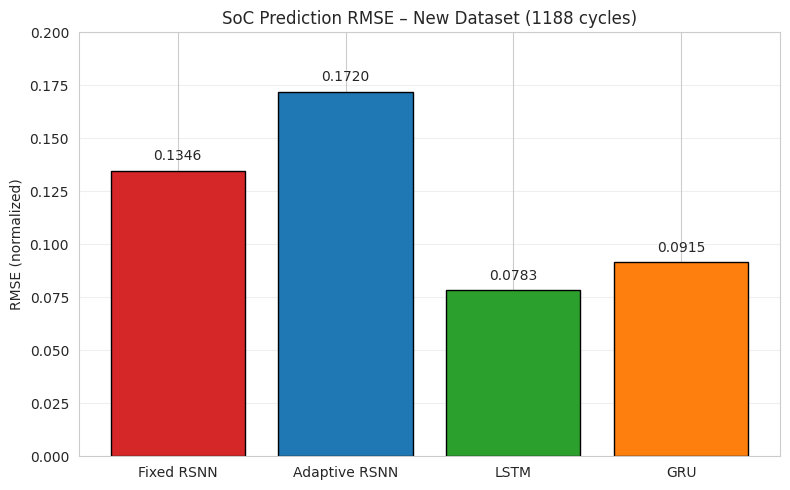

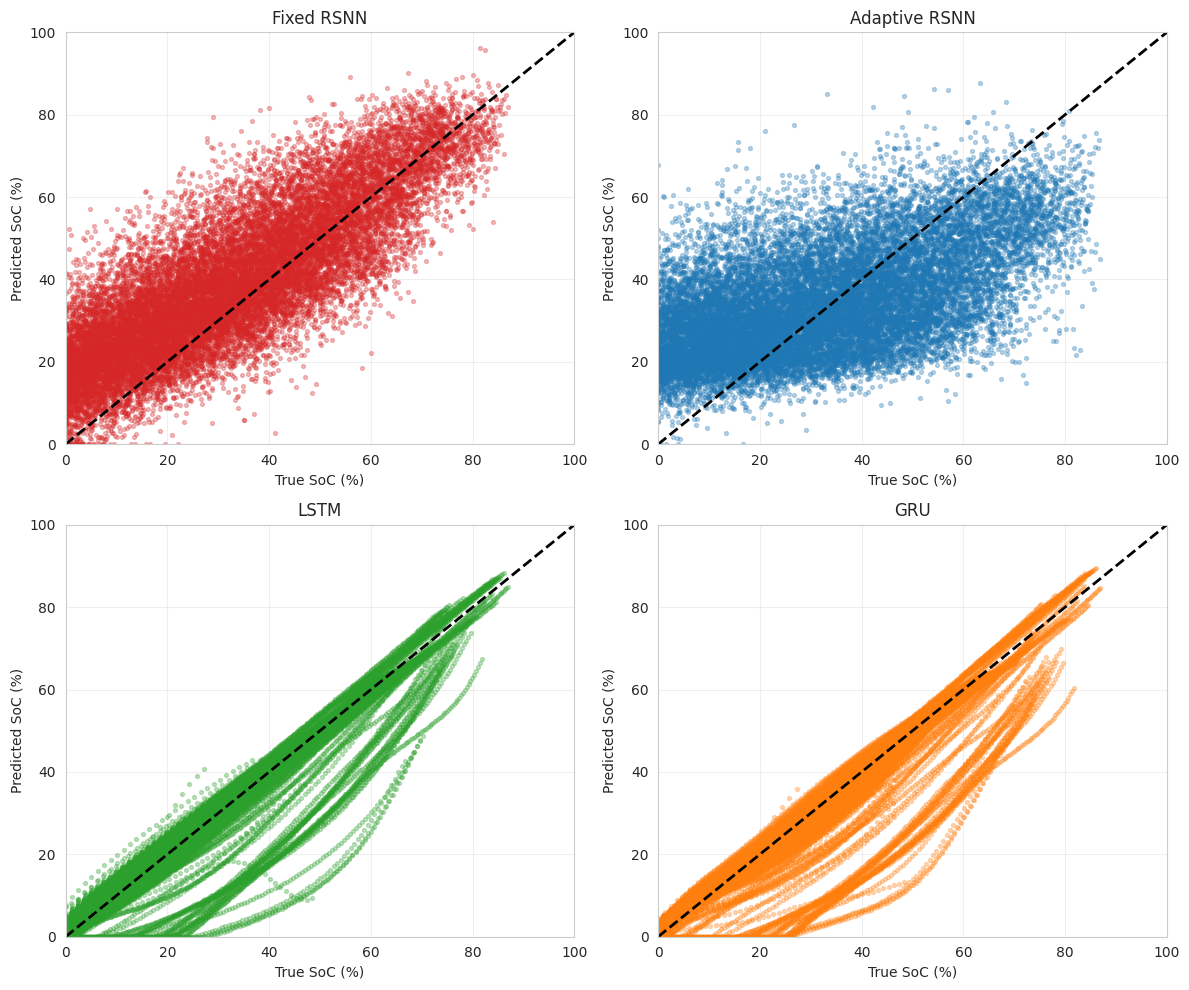

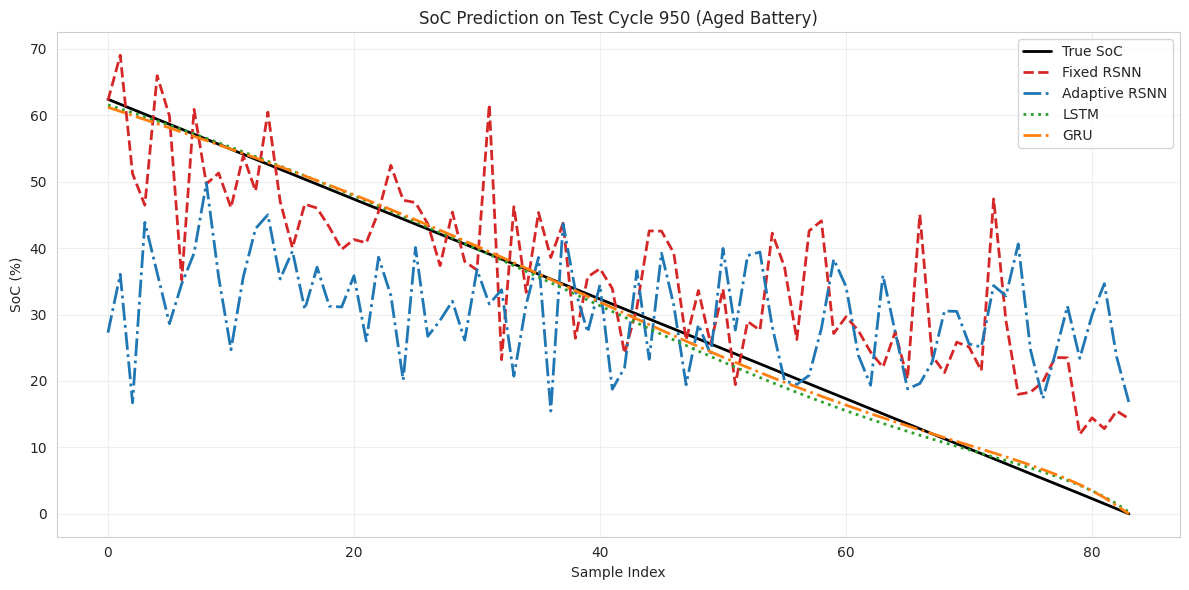

In [132]:
import matplotlib.pyplot as plt
import numpy as np

# Load predictions
y_pred_fixed = np.load('y_pred_fixed_new.npy')
y_pred_adaptive = np.load('y_pred_adaptive_new.npy')
# LSTM and GRU predictions are already in memory (y_pred_lstm_clipped, y_pred_gru_clipped)

true_all = y_test_norm * 100
pred_fixed = y_pred_fixed * 100
pred_adaptive = y_pred_adaptive * 100
pred_lstm = y_pred_lstm_clipped * 100
pred_gru = y_pred_gru_clipped * 100

# RMSE bar chart
models = ['Fixed RSNN', 'Adaptive RSNN', 'LSTM', 'GRU']
rmse_vals = [rmse_fixed, rmse_adaptive, rmse_lstm, rmse_gru]

plt.figure(figsize=(8,5))
bars = plt.bar(models, rmse_vals, color=['#d62728','#1f77b4','#2ca02c','#ff7f0e'], edgecolor='black')
plt.ylabel('RMSE (normalized)')
plt.title('SoC Prediction RMSE – New Dataset (1188 cycles)')
for bar, val in zip(bars, rmse_vals):
    plt.text(bar.get_x()+bar.get_width()/2., val+0.005, f'{val:.4f}', ha='center')
plt.ylim(0, 0.2)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('rmse_all_models_new.png', dpi=300)
plt.show()

# Scatter plots for all models
fig, axes = plt.subplots(2,2, figsize=(12,10))
ax = axes[0,0]
ax.scatter(true_all, pred_fixed, alpha=0.3, s=8, color='#d62728')
ax.plot([0,100],[0,100],'k--',linewidth=2)
ax.set_title('Fixed RSNN'); ax.set_xlabel('True SoC (%)'); ax.set_ylabel('Predicted SoC (%)')
ax.set_xlim(0,100); ax.set_ylim(0,100); ax.grid(alpha=0.3)

ax = axes[0,1]
ax.scatter(true_all, pred_adaptive, alpha=0.3, s=8, color='#1f77b4')
ax.plot([0,100],[0,100],'k--',linewidth=2)
ax.set_title('Adaptive RSNN'); ax.set_xlabel('True SoC (%)'); ax.set_ylabel('Predicted SoC (%)')
ax.set_xlim(0,100); ax.set_ylim(0,100); ax.grid(alpha=0.3)

ax = axes[1,0]
ax.scatter(true_all, pred_lstm, alpha=0.3, s=8, color='#2ca02c')
ax.plot([0,100],[0,100],'k--',linewidth=2)
ax.set_title('LSTM'); ax.set_xlabel('True SoC (%)'); ax.set_ylabel('Predicted SoC (%)')
ax.set_xlim(0,100); ax.set_ylim(0,100); ax.grid(alpha=0.3)

ax = axes[1,1]
ax.scatter(true_all, pred_gru, alpha=0.3, s=8, color='#ff7f0e')
ax.plot([0,100],[0,100],'k--',linewidth=2)
ax.set_title('GRU'); ax.set_xlabel('True SoC (%)'); ax.set_ylabel('Predicted SoC (%)')
ax.set_xlim(0,100); ax.set_ylim(0,100); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('scatter_all_models_new.png', dpi=300)
plt.show()

# Cycle prediction (first test cycle)
cycle_id = test_cycle_ids[0]
mask = (test_cycle_ids == cycle_id)
idx = np.where(mask)[0]
y_true_cycle = y_test_norm[idx] * 100

plt.figure(figsize=(12,6))
plt.plot(y_true_cycle, label='True SoC', color='black', linewidth=2)
plt.plot(pred_fixed[idx], label='Fixed RSNN', linestyle='--', color='#d62728', linewidth=2)
plt.plot(pred_adaptive[idx], label='Adaptive RSNN', linestyle='-.', color='#1f77b4', linewidth=2)
plt.plot(pred_lstm[idx], label='LSTM', linestyle=':', color='#2ca02c', linewidth=2)
plt.plot(pred_gru[idx], label='GRU', linestyle='-.', color='#ff7f0e', linewidth=2)
plt.xlabel('Sample Index'); plt.ylabel('SoC (%)')
plt.title(f'SoC Prediction on Test Cycle {cycle_id} (Aged Battery)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cycle_all_models_new.png', dpi=300)
plt.show()

In [134]:
import numpy as np
import torch
import torch.nn as nn

# Load data
X_test = np.load('X_test_seq.npy')
y_test = np.load('y_test_seq.npy')
X_train = np.load('X_train_seq.npy')  # not strictly needed, but keep for consistency

# Recreate the reservoir (with the same seed)
torch.manual_seed(42)
np.random.seed(42)

class LIFReservoir(nn.Module):
    def __init__(self, input_size, reservoir_size=200, connectivity=0.2,
                 weight_scale=0.5, decay=0.9, threshold=1.0, refractory=2):
        super().__init__()
        self.n = reservoir_size
        self.decay = decay
        self.threshold = threshold
        self.refractory = refractory
        self.W_in = nn.Parameter(torch.randn(input_size, reservoir_size) * weight_scale,
                                 requires_grad=False)
        mask = (torch.rand(reservoir_size, reservoir_size) < connectivity).float()
        self.W_rec = nn.Parameter(torch.randn(reservoir_size, reservoir_size) * weight_scale * mask,
                                  requires_grad=False)

    def forward(self, input_spikes):
        batch, T, _ = input_spikes.shape
        device = input_spikes.device
        v = torch.zeros(batch, self.n, device=device)
        refrac = torch.zeros(batch, self.n, device=device)
        all_spikes = []
        for t in range(T):
            I = torch.mm(input_spikes[:, t, :], self.W_in)
            if t > 0:
                rec_spikes = spikes_prev
                I += torch.mm(rec_spikes, self.W_rec)
            v = self.decay * v + I
            v[refrac > 0] = 0.0
            refrac = (refrac - 1).clamp(min=0)
            fired = (v >= self.threshold).float()
            spikes_prev = fired
            v[fired.bool()] = 0.0
            refrac[fired.bool()] = self.refractory
            all_spikes.append(fired)
        total_spikes = torch.stack(all_spikes, dim=1).sum(dim=1)
        return total_spikes

def population_encode(features, n_neurons=10, max_rate=200, time_steps=50):
    batch, T, F = features.shape
    centers = np.linspace(0, 1, n_neurons)
    sigma = 0.2
    feat_exp = features[:, :, :, np.newaxis]
    centers_exp = centers[np.newaxis, np.newaxis, np.newaxis, :]
    activations = np.exp(-(feat_exp - centers_exp)**2 / (2 * sigma**2))
    rates = max_rate * activations
    spike_prob = rates / 1000
    spikes = np.random.rand(*spike_prob.shape) < spike_prob
    spikes = spikes.reshape(batch, T, -1)
    return spikes.astype(np.float32)

def variance_to_maxrate(var_array, base_rate=200, var_thresh=0.05):
    scale = np.clip(var_array / var_thresh, 0.25, 2.0)
    return (base_rate * scale).astype(int)

def adaptive_population_encode_rate(features, max_rates_list, n_neurons=10):
    batch, T, F = features.shape
    all_spikes = []
    for f in range(F):
        max_rate = max_rates_list[f]
        feat_slice = features[:, :, f:f+1]
        spikes_f = population_encode(feat_slice, n_neurons=n_neurons, max_rate=max_rate, time_steps=T)
        all_spikes.append(spikes_f)
    return np.concatenate(all_spikes, axis=-1)

def fixed_encoder(batch, time_steps):
    return population_encode(batch, n_neurons=10, max_rate=200, time_steps=time_steps)

def adaptive_encoder(batch, time_steps):
    batch_size, T, F = batch.shape
    all_spikes = []
    for i in range(batch_size):
        seq = batch[i]
        var = np.var(seq, axis=0)
        max_rates = variance_to_maxrate(var, base_rate=200, var_thresh=0.05)
        seq_batch = seq[np.newaxis, :, :]
        spikes_i = adaptive_population_encode_rate(seq_batch, max_rates, n_neurons=10)
        all_spikes.append(spikes_i.squeeze(0))
    return np.stack(all_spikes, axis=0).astype(np.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
shared_reservoir = LIFReservoir(input_size=60, reservoir_size=200).to(device)

def extract_reservoir_features(sequences, encoder_func, reservoir, batch_size=256):
    N, T, F = sequences.shape
    all_features = []
    for i in range(0, N, batch_size):
        batch = sequences[i:i+batch_size]
        spikes_np = encoder_func(batch, T)
        spikes_torch = torch.tensor(spikes_np, dtype=torch.float32).to(device)
        with torch.no_grad():
            counts = reservoir(spikes_torch)
        all_features.append(counts.cpu().numpy())
    return np.vstack(all_features)

# Extract test features only (to save time)
print("Extracting fixed test features...")
fixed_test = extract_reservoir_features(X_test, fixed_encoder, shared_reservoir)
print("Extracting adaptive test features...")
adaptive_test = extract_reservoir_features(X_test, adaptive_encoder, shared_reservoir)

print(f"Fixed test shape: {fixed_test.shape}, Adaptive test shape: {adaptive_test.shape}")

Extracting fixed test features...
Extracting adaptive test features...
Fixed test shape: (19633, 200), Adaptive test shape: (19633, 200)


In [136]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances

def compute_mmd_adaptive(X, Y, sigma=None, n_samples=2000, seed=42):
    """
    Compute MMD^2 with RBF kernel and median heuristic for sigma.
    Returns MMD (not squared).
    """
    rng = np.random.RandomState(seed)
    if len(X) > n_samples:
        X = X[rng.choice(len(X), n_samples, replace=False)]
    if len(Y) > n_samples:
        Y = Y[rng.choice(len(Y), n_samples, replace=False)]

    # Standardise features (zero mean, unit variance) for meaningful distances
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    Y_scaled = scaler.transform(Y)

    # If sigma not provided, use median heuristic on combined data
    if sigma is None:
        combined = np.vstack([X_scaled, Y_scaled])
        # Sample a subset to compute median distance (tractable)
        subsample = combined[rng.choice(len(combined), min(1000, len(combined)), replace=False)]
        dists = euclidean_distances(subsample)
        sigma = np.median(dists[dists > 0])
        print(f"Using adaptive sigma = {sigma:.4f}")

    def rbf_kernel(A, B, sigma):
        A_sq = np.sum(A**2, axis=1).reshape(-1, 1)
        B_sq = np.sum(B**2, axis=1).reshape(1, -1)
        sq_dists = A_sq + B_sq - 2 * A @ B.T
        return np.exp(-sq_dists / (2 * sigma**2))

    Kxx = rbf_kernel(X_scaled, X_scaled, sigma)
    Kyy = rbf_kernel(Y_scaled, Y_scaled, sigma)
    Kxy = rbf_kernel(X_scaled, Y_scaled, sigma)

    m, n = len(X_scaled), len(Y_scaled)
    # Unbiased estimate of MMD^2
    mmd2 = (Kxx.sum() - np.trace(Kxx)) / (m*(m-1)) \
         + (Kyy.sum() - np.trace(Kyy)) / (n*(n-1)) \
         - 2 * Kxy.mean()
    mmd2 = max(mmd2, 0)  # numerical safety
    return np.sqrt(mmd2)

# Load your test features (if not already in memory)
# fixed_test, adaptive_test should be defined from your extraction.

mmd_val = compute_mmd_adaptive(fixed_test, adaptive_test)
print(f"MMD(P_fixed, P_adapt) with median sigma = {mmd_val:.4f}")

# Optionally try a few more sigmas around that value
for factor in [0.5, 1.0, 2.0]:
    mmd_s = compute_mmd_adaptive(fixed_test, adaptive_test, sigma=mmd_val * factor)
    print(f"  sigma = {mmd_val*factor:.4f}: MMD = {mmd_s:.4f}")

Using adaptive sigma = 21.7909
MMD(P_fixed, P_adapt) with median sigma = 0.5234
  sigma = 0.2617: MMD = 0.0000
  sigma = 0.5234: MMD = 0.0000
  sigma = 1.0467: MMD = 0.0000


In [138]:
import os
if os.path.exists('fixed_train_features.npy') and os.path.exists('adaptive_train_features.npy'):
    fixed_train_features = np.load('fixed_train_features.npy')
    adaptive_train_features = np.load('adaptive_train_features.npy')
    print("Loaded from files.")
else:
    print("Files not found. Will re‑extract.")

Files not found. Will re‑extract.


In [139]:
# Load training data
X_train = np.load('X_train_seq.npy')
y_train = np.load('y_train_seq.npy')
y_train_norm = y_train / 100.0

# Extract training features (if not already done)
print("Extracting fixed training features...")
fixed_train = extract_reservoir_features(X_train, fixed_encoder, shared_reservoir)
np.save('fixed_train_features.npy', fixed_train)

print("Extracting adaptive training features...")
adaptive_train = extract_reservoir_features(X_train, adaptive_encoder, shared_reservoir)
np.save('adaptive_train_features.npy', adaptive_train)

print(f"Fixed train: {fixed_train.shape}, Adaptive train: {adaptive_train.shape}")

Extracting fixed training features...
Extracting adaptive training features...
Fixed train: (189241, 200), Adaptive train: (189241, 200)


In [140]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# Train readout on adaptive training features, test on adaptive test features (in‑distribution)
readout_adapt_id = MLPRegressor(hidden_layer_sizes=(20,10), activation='relu',
                                solver='adam', max_iter=200, random_state=42, verbose=True)
readout_adapt_id.fit(adaptive_train, y_train_norm)
y_pred_adapt_id = readout_adapt_id.predict(adaptive_test)
rmse_adapt_id = np.sqrt(mean_squared_error(y_test_norm, y_pred_adapt_id))
print(f"Adaptive train → Adaptive test (in‑distribution): RMSE = {rmse_adapt_id:.4f} → {rmse_adapt_id*100:.2f}% SoC error")

# Compare with fixed‑in‑fixed baseline (if you have fixed_train)
if 'fixed_train' not in locals():
    # If not loaded, load or extract it now
    fixed_train = np.load('fixed_train_features.npy')
readout_fixed_id = MLPRegressor(hidden_layer_sizes=(20,10), activation='relu',
                                solver='adam', max_iter=200, random_state=42, verbose=True)
readout_fixed_id.fit(fixed_train, y_train_norm)
y_pred_fixed_id = readout_fixed_id.predict(fixed_test)
rmse_fixed_id = np.sqrt(mean_squared_error(y_test_norm, y_pred_fixed_id))
print(f"Fixed train → Fixed test (in‑distribution):    RMSE = {rmse_fixed_id:.4f} → {rmse_fixed_id*100:.2f}% SoC error")

Iteration 1, loss = 0.05109125
Iteration 2, loss = 0.01917686
Iteration 3, loss = 0.01651930
Iteration 4, loss = 0.01540811
Iteration 5, loss = 0.01476557
Iteration 6, loss = 0.01446399
Iteration 7, loss = 0.01423779
Iteration 8, loss = 0.01384140
Iteration 9, loss = 0.01342652
Iteration 10, loss = 0.01306416
Iteration 11, loss = 0.01277265
Iteration 12, loss = 0.01257216
Iteration 13, loss = 0.01233377
Iteration 14, loss = 0.01223740
Iteration 15, loss = 0.01213450
Iteration 16, loss = 0.01205001
Iteration 17, loss = 0.01205952
Iteration 18, loss = 0.01198718
Iteration 19, loss = 0.01192734
Iteration 20, loss = 0.01189122
Iteration 21, loss = 0.01188261
Iteration 22, loss = 0.01185121
Iteration 23, loss = 0.01182930
Iteration 24, loss = 0.01180502
Iteration 25, loss = 0.01175803
Iteration 26, loss = 0.01175063
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
Adaptive train → Adaptive test (in‑distribution): RMSE = 0.1786 → 17.86% SoC error
Iter

In [141]:
fixed_train = np.load('fixed_train_features.npy')